In [11]:
from typing import TypedDict, Literal
class PortfolioState(TypedDict):
    amount_usd : float
    total_usd: float
    target_currency: Literal["inr", "eur"]
    total: float

In [12]:
def calc_total(state : PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state : PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 95
    return state

def convert_to_eur(state : PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.9
    return state

def choose_conversion(state : PortfolioState) -> str:
    return state["target_currency"]

In [14]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(PortfolioState)

builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_node("convert_to_eur_node", convert_to_eur)

builder.add_edge(START, "calc_total_node")
builder.add_conditional_edges("calc_total_node", choose_conversion, {"inr" : "convert_to_inr_node", "eur" : "convert_to_eur_node"})
builder.add_edge(["convert_to_inr_node", "convert_to_eur_node"], END)


graph = builder.compile()

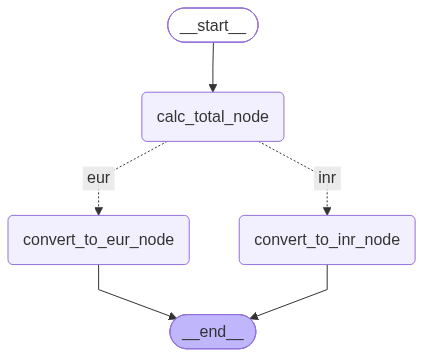

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
graph.invoke({"amount_usd" : 1000, "target_currency" : "eur"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'eur',
 'total': 972.0}